# Figure 4 analyses

This notebook keeps only the two pieces transferred from `Analyse_variats_Structures.ipynb` that are still needed here:

1. Wildtype-vs-wildtype structural alignment using TM-align.
2. Limited RMSF comparisons for selected wildtype/variant pairs.

The broader variant-aggregate and cross-family RMSF analyses are intentionally omitted.

In [1]:
from __future__ import annotations

from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'Scripts':
    PROJECT_ROOT = PROJECT_ROOT.parent

HELPER_DIR = PROJECT_ROOT / 'Scripts' / 'Helpers'
if str(HELPER_DIR) not in sys.path:
    sys.path.append(str(HELPER_DIR))

import helper_fugure4
importlib.reload(helper_fugure4)

build_symmetric_pair_metric_matrix = helper_fugure4.build_symmetric_pair_metric_matrix
build_variant_pair_summary_df = helper_fugure4.build_variant_pair_summary_df
compute_variant_delta_rmsf_df = helper_fugure4.compute_variant_delta_rmsf_df
compute_wildtype_similarity_table = helper_fugure4.compute_wildtype_similarity_table
discover_md_rmsf_catalog = helper_fugure4.discover_md_rmsf_catalog
discover_structure_families = helper_fugure4.discover_structure_families
filter_rmsf_to_allowed_variants = helper_fugure4.filter_rmsf_to_allowed_variants
filter_tm_summary_by_minimum_melting_temperature = helper_fugure4.filter_tm_summary_by_minimum_melting_temperature
filter_variant_delta_rmsf_df = helper_fugure4.filter_variant_delta_rmsf_df
load_md_rmsf_long_df = helper_fugure4.load_md_rmsf_long_df
load_tsa_tm_delta_summary = helper_fugure4.load_tsa_tm_delta_summary
build_tm_delta_row_label_map = helper_fugure4.build_tm_delta_row_label_map
build_tm_median_sort_map = helper_fugure4.build_tm_median_sort_map
plot_family_rmsf_overview = helper_fugure4.plot_family_rmsf_overview
plot_pairwise_metric_heatmap = helper_fugure4.plot_pairwise_metric_heatmap
plot_variant_pair_rmsf = helper_fugure4.plot_variant_pair_rmsf
plot_wildtype_tm_score_boxplot = helper_fugure4.plot_wildtype_tm_score_boxplot

plt.style.use('default')
pd.set_option('display.max_colwidth', 200)

In [2]:
FIGURE4_STRUCTURE_DIR = PROJECT_ROOT / 'Data' / 'Figure4'
THERMALGAN_MD_ANALYSIS_DIR = Path(
    '/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/ThermalGAN/Results/MD Analysis'
)
TSA_RESULT_SUMMARY_PATH = Path(
    '/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/ThermalGAN/Results/Assays/Thermal_Shift_Assay/Batch_3/TSA_results/TSA_results_20230905/wTSACraft_Lk9BRu/Result_summary.csv'
)
FIGURE4_OUTPUT_DIR = PROJECT_ROOT / 'Results' / 'Figure4'

TMALIGN_EXECUTABLE = None
TMALIGN_ALLOW_CA_FALLBACK = True
WT_TM_SCORE_BOXPLOT_WIDTH_MM = 30
WT_TM_SCORE_BOXPLOT_HEIGHT_MM = 50
WT_TM_PLOT_FONT_SIZE_PT = 5.5
WT_TM_PLOT_STRIP_MARKER_SIZE = 16
RMSF_OVERVIEW_FIGURE_WIDTH_MM = 150
RMSF_OVERVIEW_FIGURE_HEIGHT_MM = 100
RMSF_OVERVIEW_FONT_SIZE_PT = 5.5
RMSF_OVERVIEW_MIN_MEDIAN_TM_CELSIUS = None
RMSF_OVERVIEW_EXCLUDE_MISSING_TM = False
SAVE_RMSF_OVERVIEW_PDFS = True
# Set TMALIGN_EXECUTABLE explicitly if TM-align or USalign is installed outside PATH.
# The fallback is only for notebook smoke-tests and should not replace real WT-vs-WT TM-align.
# Set RMSF_OVERVIEW_MIN_MEDIAN_TM_CELSIUS to exclude variants below a median melting-temperature threshold.

SELECTED_RMSF_VARIANTS_BY_FAMILY = {
    'A0A372IUB3': ['A0A372IUB3_1847_model_x_0', 'A0A372IUB3_1792_model_x_0'],
    'A0A2S1LEZ1': ['A0A2S1LEZ1_362_New_17444_0', 'A0A2S1LEZ1_337_New_17444_0'],
    'MGYP001421927114': ['MGYP001421927114_1306_model_x_0', 'MGYP001421927114_1344_model_x_0'],
}

FIGURE4_STRUCTURE_DIR, THERMALGAN_MD_ANALYSIS_DIR, TSA_RESULT_SUMMARY_PATH

(PosixPath('/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/THOR_Analysis/Data/Figure4'),
 PosixPath('/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/ThermalGAN/Results/MD Analysis'),
 PosixPath('/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/ThermalGAN/Results/Assays/Thermal_Shift_Assay/Batch_3/TSA_results/TSA_results_20230905/wTSACraft_Lk9BRu/Result_summary.csv'))

## Wildtype Structural Similarity

This section keeps only the wildtype-vs-wildtype alignment from the source notebook. Variant-vs-wildtype structure comparisons are omitted.

,family_id,sample_name,pdb_path,is_wildtype
0,A0A2S1LEZ1,A0A2S1LEZ1,/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/THOR_Analysis/Data/Figure4/A0A2S1LEZ1.pdb,True
1,A0A372IUB3,A0A372IUB3,/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/THOR_Analysis/Data/Figure4/A0A372IUB3.pdb,True
2,MGYP001421927114,MGYP001421927114,/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/THOR_Analysis/Data/Figure4/MGYP001421927114.pdb,True


Wildtype similarity method: official executable at /Users/sandravi/miniforge3/envs/jupyterlab/bin/TMalign


,wildtype_a,wildtype_b,mean_tm_score,tm_score_to_wildtype_a,tm_score_to_wildtype_b,rmsd_angstrom,aligned_length,alignment_method,alignment_note
0,A0A372IUB3,MGYP001421927114,0.970890,0.98623,0.95555,0.84,308,official_tmalign,Official TM-align/USalign executable
1,A0A2S1LEZ1,A0A372IUB3,0.970475,0.96583,0.97512,0.84,305,official_tmalign,Official TM-align/USalign executable
2,A0A2S1LEZ1,MGYP001421927114,0.955765,0.96619,0.94534,1.08,308,official_tmalign,Official TM-align/USalign executable


,A0A2S1LEZ1,A0A372IUB3,MGYP001421927114
A0A2S1LEZ1,1.000000,0.970475,0.955765
A0A372IUB3,0.970475,1.000000,0.970890
MGYP001421927114,0.955765,0.970890,1.000000


,A0A2S1LEZ1,A0A372IUB3,MGYP001421927114
A0A2S1LEZ1,0.00,0.84,1.08
A0A372IUB3,0.84,0.00,0.84
MGYP001421927114,1.08,0.84,0.00


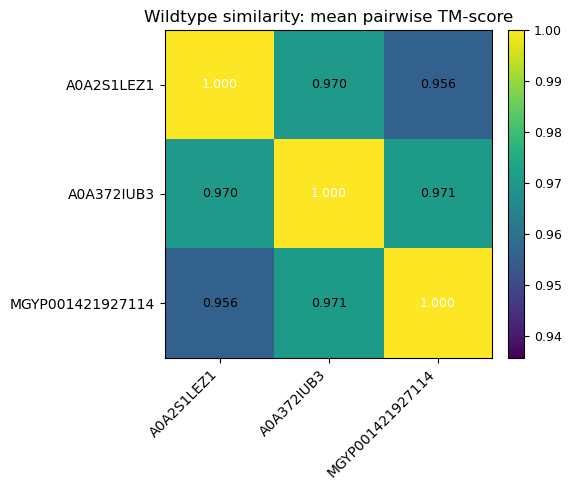

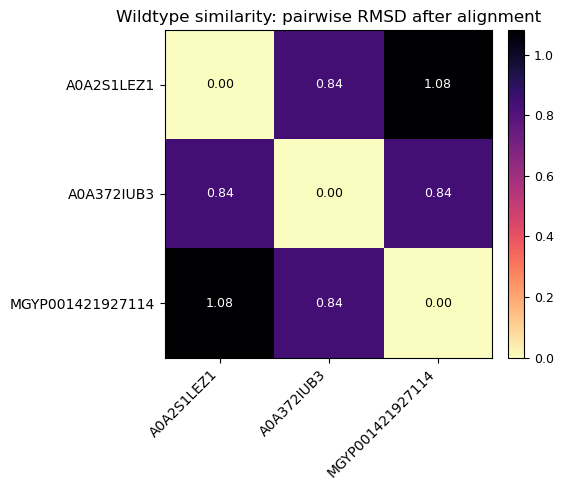

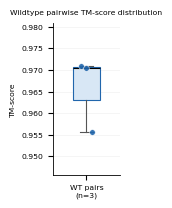

In [3]:
structure_family_df = discover_structure_families(FIGURE4_STRUCTURE_DIR)
wildtype_structure_df = structure_family_df.loc[structure_family_df['is_wildtype']].copy()

display(wildtype_structure_df)

wildtype_similarity_df, resolved_tmalign_executable = compute_wildtype_similarity_table(
    structure_family_df=structure_family_df,
    preferred_executable=TMALIGN_EXECUTABLE,
    allow_ca_fallback=TMALIGN_ALLOW_CA_FALLBACK,
)

wildtype_labels = list(wildtype_structure_df['family_id'])
wildtype_similarity_matrix_df = build_symmetric_pair_metric_matrix(
    pairwise_df=wildtype_similarity_df,
    value_column='mean_tm_score',
    diagonal_value=1.0,
    labels=wildtype_labels,
)
wildtype_rmsd_matrix_df = build_symmetric_pair_metric_matrix(
    pairwise_df=wildtype_similarity_df,
    value_column='rmsd_angstrom',
    diagonal_value=0.0,
    labels=wildtype_labels,
)

if resolved_tmalign_executable:
    print(f'Wildtype similarity method: official executable at {resolved_tmalign_executable}')
elif TMALIGN_ALLOW_CA_FALLBACK:
    print(
        'Wildtype similarity method: CA-based fallback. '
        'Set TMALIGN_EXECUTABLE to a TM-align/USalign binary for interpretable WT-vs-WT alignments.'
    )
else:
    print('Wildtype similarity method: not computed because no TM-align executable was found.')

display(
    wildtype_similarity_df[
        [
            'wildtype_a', 'wildtype_b', 'mean_tm_score',
            'tm_score_to_wildtype_a', 'tm_score_to_wildtype_b',
            'rmsd_angstrom', 'aligned_length',
            'alignment_method', 'alignment_note',
        ]
    ]
)
display(wildtype_similarity_matrix_df)
display(wildtype_rmsd_matrix_df)

tm_vmin = None
if not wildtype_similarity_matrix_df.empty:
    tm_vmin = max(
        0.0,
        float(np.nanmin(wildtype_similarity_matrix_df.to_numpy(dtype=float))) - 0.02,
    )

rmsd_vmax = None
if not wildtype_rmsd_matrix_df.empty:
    rmsd_values = wildtype_rmsd_matrix_df.to_numpy(dtype=float)
    if not np.isnan(rmsd_values).all():
        rmsd_vmax = float(np.nanmax(rmsd_values))

plot_pairwise_metric_heatmap(
    metric_matrix_df=wildtype_similarity_matrix_df,
    title='Wildtype similarity: mean pairwise TM-score',
    cmap='viridis',
    value_format='{:.3f}',
    vmin=tm_vmin,
    vmax=1.0,
)
plt.show()
plot_pairwise_metric_heatmap(
    metric_matrix_df=wildtype_rmsd_matrix_df,
    title='Wildtype similarity: pairwise RMSD after alignment',
    cmap='magma_r',
    value_format='{:.2f}',
    vmin=0.0,
    vmax=rmsd_vmax,
)
plt.show()
plot_wildtype_tm_score_boxplot(
    wildtype_similarity_df=wildtype_similarity_df,
    value_column='mean_tm_score',
    figure_width_mm=WT_TM_SCORE_BOXPLOT_WIDTH_MM,
    figure_height_mm=WT_TM_SCORE_BOXPLOT_HEIGHT_MM,
    title='Wildtype pairwise TM-score distribution',
    ylabel='TM-score',
    title_size_pt=WT_TM_PLOT_FONT_SIZE_PT,
    label_size_pt=WT_TM_PLOT_FONT_SIZE_PT,
    tick_size_pt=WT_TM_PLOT_FONT_SIZE_PT,
    strip_marker_size=WT_TM_PLOT_STRIP_MARKER_SIZE,
)
plt.savefig(f"../Results/Figure4/TMAlign_boxplot.pdf")
plt.show()

## Limited RMSF Analysis

This section keeps only selected wildtype/variant pair comparisons. The family-level aggregate and cross-family RMSF analyses from the source notebook are left out.

In [4]:
md_rmsf_catalog_df = discover_md_rmsf_catalog(
    THERMALGAN_MD_ANALYSIS_DIR,
    allowed_family_ids=wildtype_labels,
)
md_rmsf_df = load_md_rmsf_long_df(md_rmsf_catalog_df)
variant_delta_rmsf_df = compute_variant_delta_rmsf_df(md_rmsf_df)
selected_variant_delta_rmsf_df = filter_variant_delta_rmsf_df(
    variant_delta_rmsf_df,
    selected_variants_by_family=SELECTED_RMSF_VARIANTS_BY_FAMILY,
)

selected_variant_request_df = pd.DataFrame(
    [
        {'family_id': family_id, 'sample_name': sample_name}
        for family_id, sample_names in SELECTED_RMSF_VARIANTS_BY_FAMILY.items()
        for sample_name in sample_names
    ]
).drop_duplicates()

available_selected_variant_df = selected_variant_request_df.merge(
    selected_variant_delta_rmsf_df[['family_id', 'sample_name']].drop_duplicates(),
    on=['family_id', 'sample_name'],
    how='left',
    indicator=True,
)
missing_selected_variant_df = available_selected_variant_df.loc[
    available_selected_variant_df['_merge'] == 'left_only',
    ['family_id', 'sample_name'],
].reset_index(drop=True)

pairwise_rmsf_summary_df = build_variant_pair_summary_df(selected_variant_delta_rmsf_df)

selected_catalog_df = md_rmsf_catalog_df.loc[
    md_rmsf_catalog_df['is_wildtype']
    | md_rmsf_catalog_df['sample_name'].isin(selected_variant_request_df['sample_name'])
].copy()

display(
    selected_catalog_df[
        [
            'family_id', 'sample_name', 'md_sample_name', 'is_wildtype',
            'window_start_frame', 'window_stop_frame',
        ]
    ]
)

if not missing_selected_variant_df.empty:
    print('Requested RMSF pairs that were not found:')
    display(missing_selected_variant_df)

display(
    pairwise_rmsf_summary_df[
        [
            'family_id', 'sample_name', 'n_residues',
            'mean_delta_rmsf_angstrom', 'mean_abs_delta_rmsf_angstrom',
            'max_abs_delta_rmsf_angstrom', 'peak_residue_number', 'peak_delta_rmsf_angstrom',
        ]
    ]
)

,family_id,sample_name,md_sample_name,is_wildtype,window_start_frame,window_stop_frame
0,A0A2S1LEZ1,A0A2S1LEZ1,A0A2S1LEZ1_WT,True,100000,500000
1,A0A2S1LEZ1,A0A2S1LEZ1_337_New_17444_0,A0A2S1LEZ1_337_New_17444_0,False,100000,500000
4,A0A2S1LEZ1,A0A2S1LEZ1_362_New_17444_0,A0A2S1LEZ1_362_New_17444_0,False,100000,500000
9,A0A372IUB3,A0A372IUB3,A0A372IUB3_WT,True,100000,500000
13,A0A372IUB3,A0A372IUB3_1792_model_x_0,A0A372IUB3_1792_model_x_0,False,100000,500000
18,A0A372IUB3,A0A372IUB3_1847_model_x_0,A0A372IUB3_1847_model_x_0,False,100000,500000
35,MGYP001421927114,MGYP001421927114,MGYP001421927114_WT,True,100000,500000
36,MGYP001421927114,MGYP001421927114_1306_model_x_0,MGYP001421927114_1306_model_x_0,False,100000,500000
37,MGYP001421927114,MGYP001421927114_1344_model_x_0,MGYP001421927114_1344_model_x_0,False,100000,500000


,family_id,sample_name,n_residues,mean_delta_rmsf_angstrom,mean_abs_delta_rmsf_angstrom,max_abs_delta_rmsf_angstrom,peak_residue_number,peak_delta_rmsf_angstrom
0,A0A2S1LEZ1,A0A2S1LEZ1_362_New_17444_0,311,0.169775,1.072457,6.787865,221,-6.787865
1,A0A2S1LEZ1,A0A2S1LEZ1_337_New_17444_0,311,-0.001417,1.049097,6.413406,299,6.413406
2,A0A372IUB3,A0A372IUB3_1792_model_x_0,308,-1.343158,1.378277,7.817152,59,-7.817152
3,A0A372IUB3,A0A372IUB3_1847_model_x_0,308,-0.272109,0.719733,6.238048,61,-6.238048
4,MGYP001421927114,MGYP001421927114_1344_model_x_0,318,0.365426,1.445382,13.003321,49,13.003321
5,MGYP001421927114,MGYP001421927114_1306_model_x_0,318,-0.359886,0.733935,4.755583,306,-4.755583


A0A372IUB3 | A0A372IUB3_1847_model_x_0


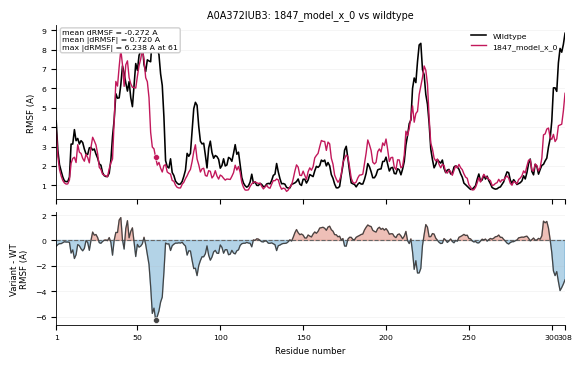

A0A372IUB3 | A0A372IUB3_1792_model_x_0


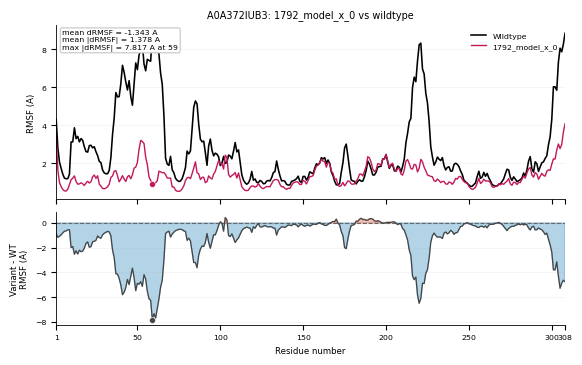

A0A2S1LEZ1 | A0A2S1LEZ1_362_New_17444_0


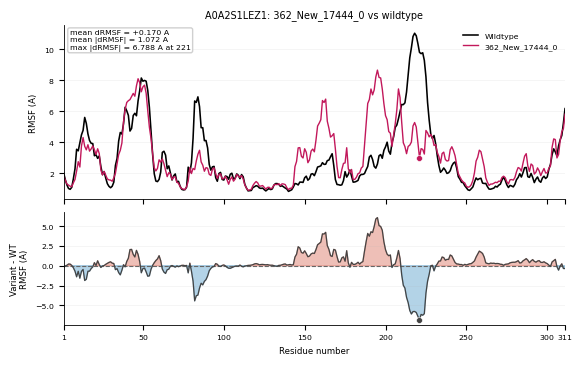

A0A2S1LEZ1 | A0A2S1LEZ1_337_New_17444_0


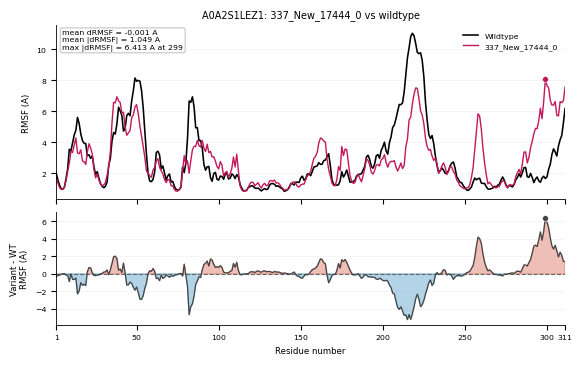

MGYP001421927114 | MGYP001421927114_1306_model_x_0


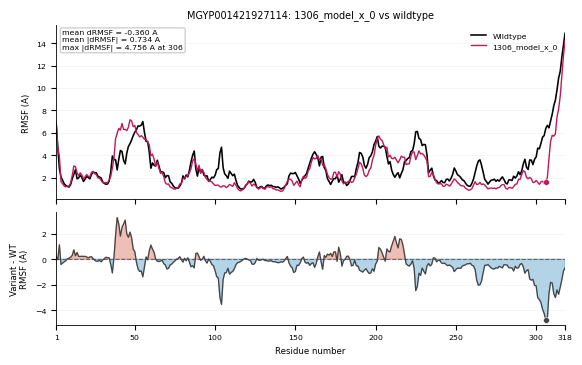

MGYP001421927114 | MGYP001421927114_1344_model_x_0


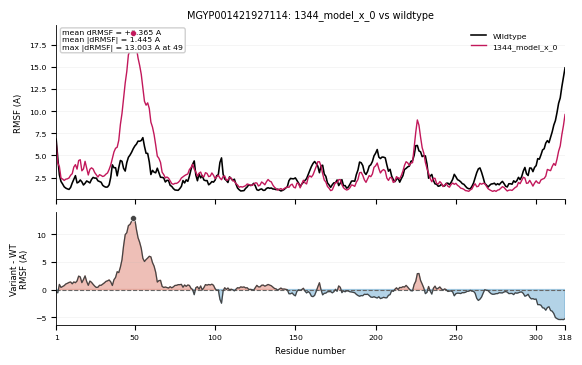

In [5]:
selected_pair_order_df = selected_variant_request_df.merge(
    pairwise_rmsf_summary_df[['family_id', 'sample_name']],
    on=['family_id', 'sample_name'],
    how='inner',
)

for row in selected_pair_order_df.itertuples(index=False):
    print(f"{row.family_id} | {row.sample_name}")
    plot_variant_pair_rmsf(
        family_id=row.family_id,
        sample_name=row.sample_name,
        md_rmsf_df=md_rmsf_df,
        variant_delta_rmsf_df=selected_variant_delta_rmsf_df,
    )
    plt.show()

## Family RMSF Overview Heatmaps

This section transfers the family RMSF overview plots from the original structure-analysis notebook. When `RMSF_OVERVIEW_MIN_MEDIAN_TM_CELSIUS` is set, variants below that median melting-temperature threshold are excluded from the overview heatmaps.

In [6]:
tm_summary_df = load_tsa_tm_delta_summary(
    result_summary_path=TSA_RESULT_SUMMARY_PATH,
    sample_catalog_df=md_rmsf_catalog_df,
)

all_rmsf_overview_variant_names = (
    md_rmsf_catalog_df.loc[~md_rmsf_catalog_df['is_wildtype'], 'sample_name']
    .dropna()
    .astype(str)
    .drop_duplicates()
    .tolist()
)

tm_variant_lookup_df = (
    tm_summary_df.loc[
        tm_summary_df['sample_name'].notna() & (~tm_summary_df['is_wildtype']),
        ['family_id', 'sample_name', 'median_tm_celsius', 'delta_tm_to_wildtype_celsius'],
    ]
    .drop_duplicates(subset=['family_id', 'sample_name'])
    .reset_index(drop=True)
)

if RMSF_OVERVIEW_MIN_MEDIAN_TM_CELSIUS is None:
    overview_tm_summary_df = tm_summary_df.copy()
    overview_allowed_variant_names = all_rmsf_overview_variant_names
    excluded_rmsf_overview_variant_df = pd.DataFrame(
        columns=[
            'family_id', 'sample_name', 'median_tm_celsius',
            'delta_tm_to_wildtype_celsius', 'exclusion_reason',
        ]
    )
else:
    overview_tm_summary_df = filter_tm_summary_by_minimum_melting_temperature(
        tm_summary_df=tm_summary_df,
        minimum_median_tm_celsius=RMSF_OVERVIEW_MIN_MEDIAN_TM_CELSIUS,
        exclude_missing_tm=RMSF_OVERVIEW_EXCLUDE_MISSING_TM,
    )
    median_tm_lookup = {
        row.sample_name: float(row.median_tm_celsius)
        for row in tm_variant_lookup_df.itertuples(index=False)
        if pd.notna(row.sample_name) and pd.notna(row.median_tm_celsius)
    }
    low_tm_variant_name_set = {
        row.sample_name
        for row in tm_variant_lookup_df.itertuples(index=False)
        if pd.notna(row.sample_name)
        and pd.notna(row.median_tm_celsius)
        and float(row.median_tm_celsius) < float(RMSF_OVERVIEW_MIN_MEDIAN_TM_CELSIUS)
    }
    measured_variant_name_set = set(tm_variant_lookup_df['sample_name'].dropna().astype(str))

    if RMSF_OVERVIEW_EXCLUDE_MISSING_TM:
        overview_allowed_variant_names = [
            sample_name
            for sample_name in all_rmsf_overview_variant_names
            if sample_name in measured_variant_name_set
            and sample_name in median_tm_lookup
            and float(median_tm_lookup[sample_name]) >= float(RMSF_OVERVIEW_MIN_MEDIAN_TM_CELSIUS)
        ]
    else:
        overview_allowed_variant_names = [
            sample_name
            for sample_name in all_rmsf_overview_variant_names
            if sample_name not in low_tm_variant_name_set
        ]

    excluded_variant_rows = []
    for sample_name in all_rmsf_overview_variant_names:
        if sample_name in overview_allowed_variant_names:
            continue
        tm_match_df = tm_variant_lookup_df.loc[tm_variant_lookup_df['sample_name'] == sample_name]
        if tm_match_df.empty:
            family_id = sample_name.split('_', 1)[0]
            median_tm = np.nan
            delta_tm = np.nan
            reason = 'missing Tm'
        else:
            family_id = tm_match_df['family_id'].iloc[0]
            median_tm = tm_match_df['median_tm_celsius'].iloc[0]
            delta_tm = tm_match_df['delta_tm_to_wildtype_celsius'].iloc[0]
            if pd.isna(median_tm):
                reason = 'missing Tm'
            else:
                reason = f"median Tm < {float(RMSF_OVERVIEW_MIN_MEDIAN_TM_CELSIUS):0.1f} C"
        excluded_variant_rows.append(
            {
                'family_id': family_id,
                'sample_name': sample_name,
                'median_tm_celsius': median_tm,
                'delta_tm_to_wildtype_celsius': delta_tm,
                'exclusion_reason': reason,
            }
        )

    excluded_rmsf_overview_variant_df = pd.DataFrame(excluded_variant_rows)
    if not excluded_rmsf_overview_variant_df.empty:
        excluded_rmsf_overview_variant_df = excluded_rmsf_overview_variant_df.sort_values(
            ['family_id', 'median_tm_celsius', 'sample_name'],
            ascending=[True, True, True],
        ).reset_index(drop=True)

overview_md_rmsf_df, overview_variant_delta_rmsf_df = filter_rmsf_to_allowed_variants(
    md_rmsf_df=md_rmsf_df,
    variant_delta_rmsf_df=variant_delta_rmsf_df,
    allowed_variant_names=overview_allowed_variant_names,
)

overview_rmsf_tm_row_label_map = build_tm_delta_row_label_map(overview_tm_summary_df)
overview_rmsf_tm_sort_map = build_tm_median_sort_map(overview_tm_summary_df)

overview_variant_count_df = (
    overview_variant_delta_rmsf_df[['family_id', 'sample_name']]
    .drop_duplicates()
    .groupby('family_id', as_index=False)
    .agg(n_variants_plotted=('sample_name', 'size'))
)

display(overview_variant_count_df)

if RMSF_OVERVIEW_MIN_MEDIAN_TM_CELSIUS is not None and not excluded_rmsf_overview_variant_df.empty:
    display(excluded_rmsf_overview_variant_df)


,family_id,n_variants_plotted
0,A0A2S1LEZ1,8
1,A0A372IUB3,25
2,MGYP001421927114,6


A0A2S1LEZ1
/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/THOR_Analysis/Results/Figure4/Structure_A0A2S1LEZ1_RMSF.pdf


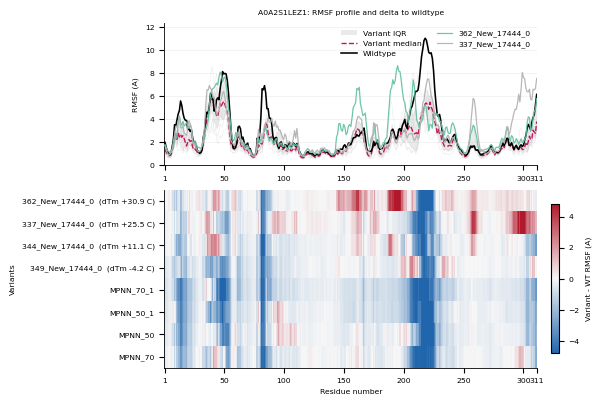

A0A372IUB3
/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/THOR_Analysis/Results/Figure4/Structure_A0A372IUB3_RMSF.pdf


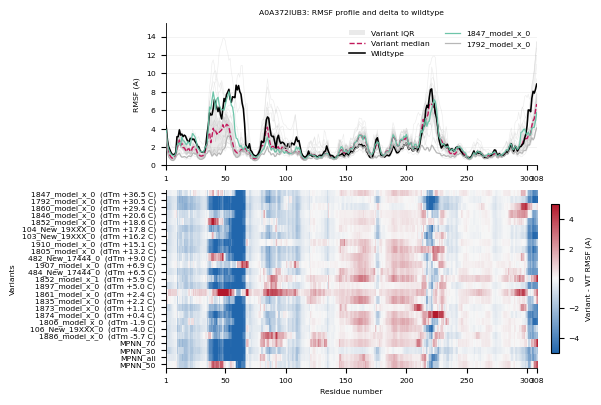

MGYP001421927114
/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/THOR_Analysis/Results/Figure4/Structure_MGYP001421927114_RMSF.pdf


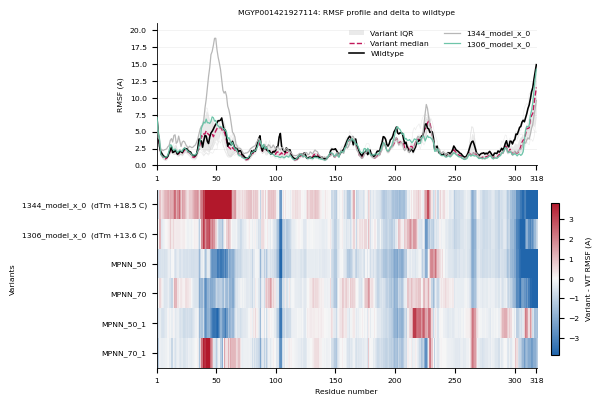

In [7]:
if SAVE_RMSF_OVERVIEW_PDFS:
    FIGURE4_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for family_id in wildtype_labels:
    family_variant_count_series = overview_variant_count_df.loc[
        overview_variant_count_df['family_id'] == family_id,
        'n_variants_plotted',
    ]
    if family_variant_count_series.empty or int(family_variant_count_series.iloc[0]) == 0:
        print(f"{family_id}: no variants remain after the Tm filter")
        continue

    print(family_id)
    family_figure = plot_family_rmsf_overview(
        family_id=family_id,
        md_rmsf_df=overview_md_rmsf_df,
        variant_delta_rmsf_df=overview_variant_delta_rmsf_df,
        selected_variant_names=SELECTED_RMSF_VARIANTS_BY_FAMILY.get(family_id),
        sample_row_label_map=overview_rmsf_tm_row_label_map,
        sample_sort_value_map=overview_rmsf_tm_sort_map,
        figure_width_mm=RMSF_OVERVIEW_FIGURE_WIDTH_MM,
        figure_height_mm=RMSF_OVERVIEW_FIGURE_HEIGHT_MM,
        title_size_pt=RMSF_OVERVIEW_FONT_SIZE_PT,
        label_size_pt=RMSF_OVERVIEW_FONT_SIZE_PT,
        tick_size_pt=RMSF_OVERVIEW_FONT_SIZE_PT,
        legend_size_pt=RMSF_OVERVIEW_FONT_SIZE_PT,
    )
    if SAVE_RMSF_OVERVIEW_PDFS:
        output_path = FIGURE4_OUTPUT_DIR / f"Structure_{family_id}_RMSF.pdf"
        family_figure.savefig(output_path, bbox_inches='tight')
        print(output_path)
    plt.show()


In [8]:
df_MD_with_rep = pd.read_csv("../Data/Figure4/all_systems_rmsf_0_100000.csv" ) 

In [9]:
df_MD_with_rep

,system,replicate,replicate_index,metric,start,stop,source_file,Frame,RMSF
0,A0A2S1LEZ1,rep1,1,rmsf,0,100000,A0A2S1LEZ1/rep1/rmsf_0_100000.csv,1.0,1.193342
1,A0A2S1LEZ1,rep1,1,rmsf,0,100000,A0A2S1LEZ1/rep1/rmsf_0_100000.csv,2.0,0.974657
2,A0A2S1LEZ1,rep1,1,rmsf,0,100000,A0A2S1LEZ1/rep1/rmsf_0_100000.csv,3.0,0.827794
3,A0A2S1LEZ1,rep1,1,rmsf,0,100000,A0A2S1LEZ1/rep1/rmsf_0_100000.csv,4.0,0.784146
4,A0A2S1LEZ1,rep1,1,rmsf,0,100000,A0A2S1LEZ1/rep1/rmsf_0_100000.csv,5.0,0.750205
...,...,...,...,...,...,...,...,...,...
20449,MGYP001421927114_1344_model_x_0,rep3,3,rmsf,0,100000,MGYP001421927114_1344_model_x_0/rep3/rmsf_0_100000.csv,314.0,2.979842
20450,MGYP001421927114_1344_model_x_0,rep3,3,rmsf,0,100000,MGYP001421927114_1344_model_x_0/rep3/rmsf_0_100000.csv,315.0,3.275130
20451,MGYP001421927114_1344_model_x_0,rep3,3,rmsf,0,100000,MGYP001421927114_1344_model_x_0/rep3/rmsf_0_100000.csv,316.0,4.240575
20452,MGYP001421927114_1344_model_x_0,rep3,3,rmsf,0,100000,MGYP001421927114_1344_model_x_0/rep3/rmsf_0_100000.csv,317.0,5.184216


,family_id,sample_name,is_wildtype,median_tm_celsius,delta_tm_to_wildtype_celsius
0,A0A2S1LEZ1,A0A2S1LEZ1,True,40.4335,0.0000
1,A0A2S1LEZ1,A0A2S1LEZ1_362_New_17444_0,False,71.3416,30.9081
2,A0A2S1LEZ1,A0A2S1LEZ1_337_New_17444_0,False,65.9163,25.4828
3,A0A2S1LEZ1,A0A2S1LEZ1_344_New_17444_0,False,51.5084,11.0749
4,A0A372IUB3,A0A372IUB3,True,55.9120,0.0000
5,A0A372IUB3,A0A372IUB3_1847_model_x_0,False,92.3836,36.4716
6,A0A372IUB3,A0A372IUB3_1792_model_x_0,False,86.3846,30.4726
7,A0A372IUB3,A0A372IUB3_1860_model_x_0,False,85.3535,29.4415
8,A0A372IUB3,A0A372IUB3_1846_model_x_0,False,76.5092,20.5972
9,A0A372IUB3,A0A372IUB3_1852_model_x_0,False,74.5336,18.6216


,family_id,sample_name,n_replicates,median_tm_celsius,delta_tm_to_wildtype_celsius,mean_abs_delta_rmsf_angstrom,max_abs_delta_rmsf_angstrom,peak_residue_number
0,A0A2S1LEZ1,A0A2S1LEZ1_362_New_17444_0,3,71.3416,30.9081,0.554125,1.891250,207
1,A0A2S1LEZ1,A0A2S1LEZ1_337_New_17444_0,3,65.9163,25.4828,0.329043,2.175615,217
2,A0A2S1LEZ1,A0A2S1LEZ1_344_New_17444_0,3,51.5084,11.0749,0.509480,3.157392,85
3,A0A372IUB3,A0A372IUB3_1847_model_x_0,3,92.3836,36.4716,0.219077,1.857573,220
4,A0A372IUB3,A0A372IUB3_1792_model_x_0,3,86.3846,30.4726,0.207850,1.928290,308
5,A0A372IUB3,A0A372IUB3_1860_model_x_0,3,85.3535,29.4415,0.316759,2.033185,224
6,A0A372IUB3,A0A372IUB3_1846_model_x_0,3,76.5092,20.5972,0.272883,1.757591,51
7,A0A372IUB3,A0A372IUB3_1852_model_x_0,3,74.5336,18.6216,0.207735,1.876621,42
8,A0A372IUB3,A0A372IUB3_104_New_19XXX_0,3,73.7585,17.8465,0.306525,2.338270,225
9,A0A372IUB3,A0A372IUB3_103_New_19XXX_0,3,72.1360,16.2240,0.309629,2.716886,39


A0A2S1LEZ1 | replica comparison grid
/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/THOR_Analysis/Results/Figure4/Structure_A0A2S1LEZ1_RMSF_replicas_dTm_ge_5C.pdf


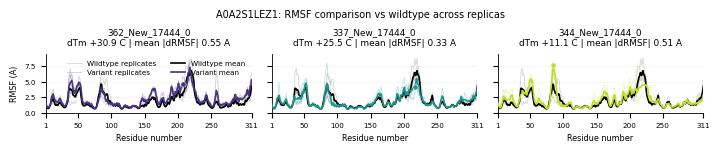

A0A2S1LEZ1 | replica-mean delta heatmap
/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/THOR_Analysis/Results/Figure4/Structure_A0A2S1LEZ1_RMSF_replica_mean_heatmap_dTm_ge_5C.pdf


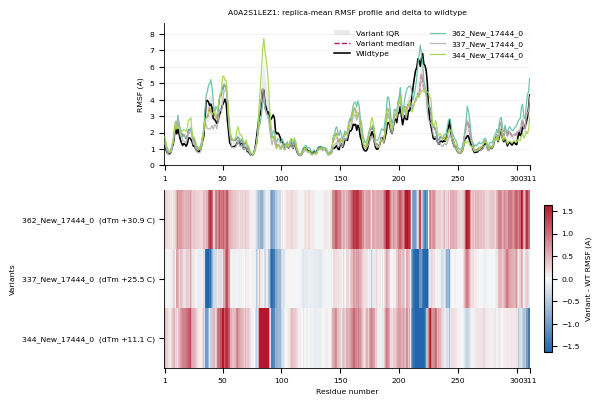

A0A372IUB3 | replica comparison grid
/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/THOR_Analysis/Results/Figure4/Structure_A0A372IUB3_RMSF_replicas_dTm_ge_5C.pdf


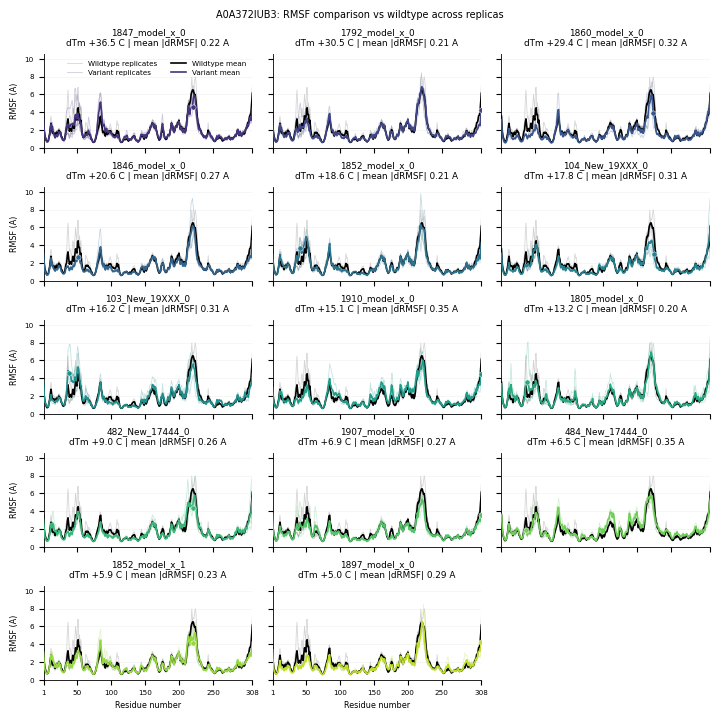

A0A372IUB3 | replica-mean delta heatmap
/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/THOR_Analysis/Results/Figure4/Structure_A0A372IUB3_RMSF_replica_mean_heatmap_dTm_ge_5C.pdf


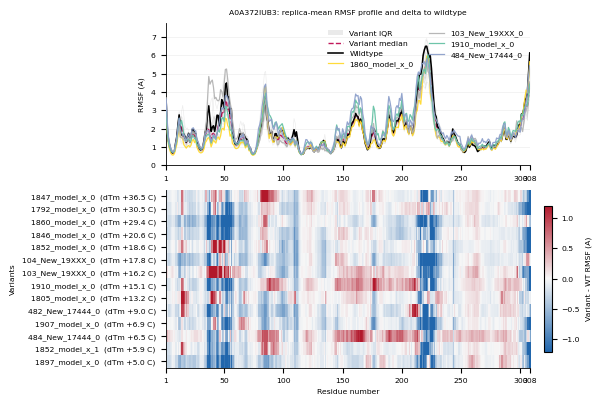

MGYP001421927114 | replica comparison grid
/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/THOR_Analysis/Results/Figure4/Structure_MGYP001421927114_RMSF_replicas_dTm_ge_5C.pdf


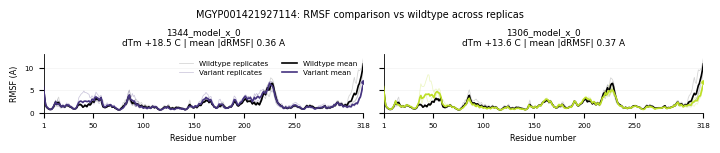

MGYP001421927114 | replica-mean delta heatmap
/Users/sandravi/Library/CloudStorage/OneDrive-Chalmers/Documents/Projects/THOR_Analysis/Results/Figure4/Structure_MGYP001421927114_RMSF_replica_mean_heatmap_dTm_ge_5C.pdf


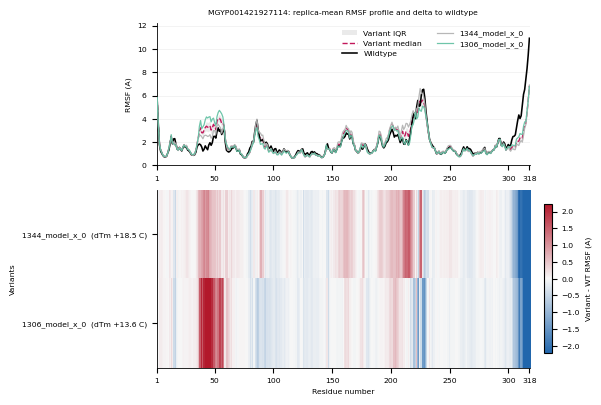

In [11]:
importlib.reload(helper_fugure4)

REPLICA_RMSF_MIN_DELTA_TM_CELSIUS = 5.0
SAVE_RMSF_REPLICA_COMPARISON_PDFS = True
SAVE_RMSF_REPLICA_HEATMAP_PDFS = True
RMSF_REPLICA_FIGURE_WIDTH_MM = 180
RMSF_REPLICA_PANEL_HEIGHT_MM = 36
RMSF_REPLICA_MAX_COLUMNS = 3
RMSF_REPLICA_HEATMAP_WIDTH_MM = 150
RMSF_REPLICA_HEATMAP_HEIGHT_MM = 100
RMSF_REPLICA_HEATMAP_FONT_SIZE_PT = 5.5

if 'md_rmsf_catalog_df' not in globals():
    md_rmsf_catalog_df = discover_md_rmsf_catalog(
        THERMALGAN_MD_ANALYSIS_DIR,
        allowed_family_ids=wildtype_labels,
    )

if 'tm_summary_df' not in globals():
    tm_summary_df = load_tsa_tm_delta_summary(
        result_summary_path=TSA_RESULT_SUMMARY_PATH,
        sample_catalog_df=md_rmsf_catalog_df,
    )

replica_system_metadata_df = (
    pd.DataFrame({'sample_name': sorted(df_MD_with_rep['system'].astype(str).unique())})
    .merge(
        md_rmsf_catalog_df[['family_id', 'sample_name', 'is_wildtype']].drop_duplicates(),
        on='sample_name',
        how='left',
    )
    .merge(
        tm_summary_df[
            ['family_id', 'sample_name', 'median_tm_celsius', 'delta_tm_to_wildtype_celsius']
        ].drop_duplicates(),
        on=['family_id', 'sample_name'],
        how='left',
    )
)

unmatched_replica_system_df = replica_system_metadata_df.loc[
    replica_system_metadata_df['family_id'].isna()
].copy()
if not unmatched_replica_system_df.empty:
    print('Replica systems without family/sample metadata:')
    display(unmatched_replica_system_df)

replica_system_selection_df = (
    pd.concat(
        [
            replica_system_metadata_df.loc[replica_system_metadata_df['is_wildtype']],
            replica_system_metadata_df.loc[
                (~replica_system_metadata_df['is_wildtype'])
                & replica_system_metadata_df['delta_tm_to_wildtype_celsius'].ge(
                    REPLICA_RMSF_MIN_DELTA_TM_CELSIUS
                )
            ],
        ],
        ignore_index=True,
    )
    .dropna(subset=['family_id'])
    .drop_duplicates(subset=['family_id', 'sample_name'])
    .sort_values(
        ['family_id', 'is_wildtype', 'delta_tm_to_wildtype_celsius', 'sample_name'],
        ascending=[True, False, False, True],
    )
    .reset_index(drop=True)
)

display(
    replica_system_selection_df[
        [
            'family_id',
            'sample_name',
            'is_wildtype',
            'median_tm_celsius',
            'delta_tm_to_wildtype_celsius',
        ]
    ]
)

replica_rmsf_df = (
    df_MD_with_rep
    .rename(
        columns={
            'system': 'sample_name',
            'Frame': 'residue_number',
            'RMSF': 'rmsf_angstrom',
        }
    )
    .assign(
        sample_name=lambda df: df['sample_name'].astype(str),
        replicate=lambda df: df['replicate'].astype(str),
        residue_number=lambda df: pd.to_numeric(df['residue_number'], errors='coerce'),
        rmsf_angstrom=lambda df: pd.to_numeric(df['rmsf_angstrom'], errors='coerce'),
    )
    .dropna(subset=['residue_number', 'rmsf_angstrom'])
    .assign(residue_number=lambda df: df['residue_number'].round().astype(int))
    .merge(replica_system_selection_df, on='sample_name', how='inner')
    .sort_values(
        ['family_id', 'is_wildtype', 'sample_name', 'replicate_index', 'residue_number'],
        ascending=[True, False, True, True, True],
    )
    .reset_index(drop=True)
)

replica_profile_stats_df = helper_fugure4.compute_replica_rmsf_statistics(replica_rmsf_df)
replica_pair_summary_df = helper_fugure4.build_replica_variant_pair_summary_df(
    replica_profile_stats_df,
    variant_metadata_df=replica_system_selection_df,
)
replica_mean_rmsf_df = (
    replica_profile_stats_df[
        [
            'family_id',
            'sample_name',
            'is_wildtype',
            'residue_number',
            'mean_rmsf_angstrom',
        ]
    ]
    .rename(columns={'mean_rmsf_angstrom': 'rmsf_angstrom'})
    .reset_index(drop=True)
)
replica_mean_delta_rmsf_df = compute_variant_delta_rmsf_df(replica_mean_rmsf_df)
replica_heatmap_row_label_map = build_tm_delta_row_label_map(replica_system_selection_df)
replica_heatmap_sort_map = build_tm_median_sort_map(replica_system_selection_df)

display(
    replica_pair_summary_df[
        [
            'family_id',
            'sample_name',
            'n_replicates',
            'median_tm_celsius',
            'delta_tm_to_wildtype_celsius',
            'mean_abs_delta_rmsf_angstrom',
            'max_abs_delta_rmsf_angstrom',
            'peak_residue_number',
        ]
    ]
)

if SAVE_RMSF_REPLICA_COMPARISON_PDFS or SAVE_RMSF_REPLICA_HEATMAP_PDFS:
    FIGURE4_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for family_id in replica_pair_summary_df['family_id'].drop_duplicates():
    print(f"{family_id} | replica comparison grid")
    family_figure, family_axes = helper_fugure4.plot_family_replica_rmsf_grid(
        family_id=family_id,
        replica_rmsf_df=replica_rmsf_df,
        variant_metadata_df=replica_system_selection_df,
        figure_width_mm=RMSF_REPLICA_FIGURE_WIDTH_MM,
        panel_height_mm=RMSF_REPLICA_PANEL_HEIGHT_MM,
        max_columns=RMSF_REPLICA_MAX_COLUMNS,
    )
    if SAVE_RMSF_REPLICA_COMPARISON_PDFS:
        output_path = (
            FIGURE4_OUTPUT_DIR
            / f"Structure_{family_id}_RMSF_replicas_dTm_ge_{int(REPLICA_RMSF_MIN_DELTA_TM_CELSIUS)}C.pdf"
        )
        family_figure.savefig(output_path, bbox_inches='tight')
        print(output_path)
    plt.show()

    print(f"{family_id} | replica-mean delta heatmap")
    family_heatmap_figure = plot_family_rmsf_overview(
        family_id=family_id,
        md_rmsf_df=replica_mean_rmsf_df,
        variant_delta_rmsf_df=replica_mean_delta_rmsf_df,
        sample_row_label_map=replica_heatmap_row_label_map,
        sample_sort_value_map=replica_heatmap_sort_map,
        figure_width_mm=RMSF_REPLICA_HEATMAP_WIDTH_MM,
        figure_height_mm=RMSF_REPLICA_HEATMAP_HEIGHT_MM,
        title_size_pt=RMSF_REPLICA_HEATMAP_FONT_SIZE_PT,
        label_size_pt=RMSF_REPLICA_HEATMAP_FONT_SIZE_PT,
        tick_size_pt=RMSF_REPLICA_HEATMAP_FONT_SIZE_PT,
        legend_size_pt=RMSF_REPLICA_HEATMAP_FONT_SIZE_PT,
    )
    family_heatmap_figure.axes[0].set_title(
        f"{family_id}: replica-mean RMSF profile and delta to wildtype",
        fontsize=RMSF_REPLICA_HEATMAP_FONT_SIZE_PT,
    )
    if SAVE_RMSF_REPLICA_HEATMAP_PDFS:
        heatmap_output_path = (
            FIGURE4_OUTPUT_DIR
            / f"Structure_{family_id}_RMSF_replica_mean_heatmap_dTm_ge_{int(REPLICA_RMSF_MIN_DELTA_TM_CELSIUS)}C.pdf"
        )
        family_heatmap_figure.savefig(heatmap_output_path, bbox_inches='tight')
        print(heatmap_output_path)
    plt.show()
